In [28]:
import pandas as pd
import geopandas as gpd
import missingno
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde
from scipy.integrate import simps
import sys
from sklearn.metrics.pairwise import euclidean_distances

sys.path.insert(0, "../../Modules")

from utils import *

enc = 'utf-8' 
dec = 'greek8'

In [29]:
raw_data = pd.read_csv('../data/GR_WNV_cases_GRID_2022-2024_original.csv', encoding = enc)
raw_data.head(5)

,Α/Α,Id διαχείρισης δεδομένων,Έτος,Ηλικία \r\n(σε έτη),Φύλο,Ημ/νία έναρξης συμπτωμάτων,Date used for statistics,"Προσβολή ΚΝΣ (1 = NAI, 0 = OXI)",Περιφέρεια πιθανής έκθεσης,Περιφερειακή Ενότητα πιθανής έκθεσης,Δήμος πιθανής έκθεσης,Πόλη/χωριό (/συνοικία Αθήνας ή Θεσσαλονίκης) πιθανής έκθεσης,Κωδικός κανάβου κελιού 1x1 χλμ πιθανής έκθεσης,PageNumber
0,1,1443,2022,65.0,ΑΡΡΕΝ,23-06-22,23-06-22,1,ΚΕΝΤΡΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ,ΘΕΣΣΑΛΟΝΙΚΗΣ,ΑΜΠΕΛΟΚΗΠΩΝ - ΜΕΝΕΜΕΝΗΣ,ΑΜΠΕΛΟΚΗΠΟΙ,DU305,28261.0
1,2,1444,2022,72.0,ΑΡΡΕΝ,05-07-22,05-07-22,1,ΚΕΝΤΡΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ,ΘΕΣΣΑΛΟΝΙΚΗΣ,ΔΕΛΤΑ,ΑΝΑΤΟΛΙΚΟ,DS287,27744.0
2,3,1445,2022,78.0,ΑΡΡΕΝ,06-07-22,06-07-22,1,ΚΕΝΤΡΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ,ΘΕΣΣΑΛΟΝΙΚΗΣ,ΧΑΛΚΗΔΟΝΟΣ,ΒΑΘΥΛΑΚΚΟΣ,DG288,24544.0
3,4,1446,2022,73.0,ΑΡΡΕΝ,04-07-22,04-07-22,1,ΚΕΝΤΡΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ,ΘΕΣΣΑΛΟΝΙΚΗΣ,ΔΕΛΤΑ,ΧΑΛΑΣΤΡΑ,DX289,29003.0
4,5,1447,2022,76.0,ΑΡΡΕΝ,05-07-22,05-07-22,1,ΘΕΣΣΑΛΙΑΣ,ΛΑΡΙΣΑΣ,ΤΕΜΠΩΝ,ΧΕΙΜΑΔΙ,HT273,52950.0


In [30]:
raw_data.shape

(667, 14)

In [31]:
dataset = raw_data.set_axis(['idx', 'id', 'year', 'age', 'sex', 'onset of symptoms', 'dt_placement', 'cns attack', 'nuts2', 'nuts3', 'lau1', 'lau2', 'cell_code', 'unnamed1'], axis=1)
dataset.drop(columns = ['idx', 'id', 'cns attack', 'unnamed1', 'onset of symptoms'], inplace = True)
dataset = dataset.dropna(subset=['cell_code'])

In [32]:
mask_bad = pd.to_datetime(dataset['dt_placement'],format='%d-%m-%y',errors='coerce').isna() & dataset['dt_placement'].notna()

bad_rows = dataset[mask_bad]
bad_rows

,year,age,sex,dt_placement,nuts2,nuts3,lau1,lau2,cell_code
539,2024,77.0,ΑΡΡΕΝ,9 Αύγουστος 2024,ΑΝΑΤΟΛΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ ΚΑΙ ΘΡΑΚΗΣ,ΘΑΣΟΥ,ΘΑΣΟΥ,"ΣΚΑΛΑ ΣΩΤΗΡΟΣ, ΘΑΣΟΣ",DM443
540,2024,71.0,ΑΡΡΕΝ,9 Αύγουστος 2024,ΙΟΝΙΩΝ ΝΗΣΩΝ,ΛΕΥΚΑΔΑΣ,ΛΕΥΚΑΔΑΣ,ΝΥΔΡΙ,MB111
541,2024,71.0,ΑΡΡΕΝ,11 Αύγουστος 2024,ΑΝΑΤΟΛΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ ΚΑΙ ΘΡΑΚΗΣ,ΕΒΡΟΥ,ΟΡΕΣΤΙΑΔΑΣ,"ΟΡΕΣΤΙΑΔΑ, ΣΑΓΗΝΗ",AC607
553,2024,70.0,ΑΡΡΕΝ,29 Ιούλιος 2024,ΣΤΕΡΕΑΣ ΕΛΛΑΔΑΣ,ΒΟΙΩΤΙΑΣ,ΟΡΧΟΜΕΝΟΥ,ΠΑΥΛΟΣ,MV317
561,2024,85.0,ΑΡΡΕΝ,17 Αύγουστος 2024,ΑΤΤΙΚΗΣ,ΑΝΑΤΟΛΙΚΗΣ ΑΤΤΙΚΗΣ,ΣΑΡΩΝΙΚΟΥ,ΘΥΜΑΡΙ,QK391
569,2024,73.0,ΘΗΛΥ,08 Αύγουστος 2024,ΔΥΤΙΚΗΣ ΕΛΛΑΔΑΣ,ΗΛΕΙΑΣ,ΑΝΔΡΑΒΙΔΑΣ - ΚΥΛΛΗΝΗΣ,ΝΕΑ ΜΑΝΩΛΑΔΑ,OU166


In [33]:
fixes = {
    539: '09-08-24',
    540: '09-08-24',
    541: '11-08-24',
    553: '29-07-24',
    561: '17-08-24',
    569: '08-08-24',
}

for idx, val in fixes.items():
    dataset.loc[idx, 'dt_placement'] = val

In [34]:
mask_bad = pd.to_datetime(dataset['dt_placement'],format='%d-%m-%y',errors='coerce').isna() & dataset['dt_placement'].notna()

bad_rows = dataset[mask_bad]
bad_rows

,year,age,sex,dt_placement,nuts2,nuts3,lau1,lau2,cell_code


In [35]:
dataset['dt_placement'] = pd.to_datetime(dataset['dt_placement'],format='%d-%m-%y',errors='raise')
dataset.loc[dataset['lau1'] == 'ΠΙΘΑΝΟΤΕΡΟΣ: ΝΕΑΣ ΠΡΟΠΟΝΤΙΔΑΣ', 'lau1'] = 'ΝΕΑΣ ΠΡΟΠΟΝΤΙΔΑΣ'
dataset.loc[dataset['nuts3'] == 'ΠΙΘΑΝΟΤΕΡΗ: ΧΑΛΚΙΔΙΚΗΣ', 'nuts3'] = 'ΧΑΛΚΙΔΙΚΗΣ'
dataset['cases'] = 1

In [36]:
dataset.reset_index(drop=True, inplace = True)
dataset.shape

(656, 10)

In [37]:
df_missign = describe_dataframe(dataset)

df_missign

,Column,Missing
0,year,0.0
1,age,0.0
2,sex,0.0
3,dt_placement,0.0
4,nuts2,0.0
5,nuts3,0.0
6,lau1,0.0
7,lau2,0.0
8,cell_code,0.0
9,cases,0.0


In [38]:
dataset

,year,age,sex,dt_placement,nuts2,nuts3,lau1,lau2,cell_code,cases
0,2022,65.0,ΑΡΡΕΝ,2022-06-23,ΚΕΝΤΡΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ,ΘΕΣΣΑΛΟΝΙΚΗΣ,ΑΜΠΕΛΟΚΗΠΩΝ - ΜΕΝΕΜΕΝΗΣ,ΑΜΠΕΛΟΚΗΠΟΙ,DU305,1
1,2022,72.0,ΑΡΡΕΝ,2022-07-05,ΚΕΝΤΡΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ,ΘΕΣΣΑΛΟΝΙΚΗΣ,ΔΕΛΤΑ,ΑΝΑΤΟΛΙΚΟ,DS287,1
2,2022,78.0,ΑΡΡΕΝ,2022-07-06,ΚΕΝΤΡΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ,ΘΕΣΣΑΛΟΝΙΚΗΣ,ΧΑΛΚΗΔΟΝΟΣ,ΒΑΘΥΛΑΚΚΟΣ,DG288,1
3,2022,73.0,ΑΡΡΕΝ,2022-07-04,ΚΕΝΤΡΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ,ΘΕΣΣΑΛΟΝΙΚΗΣ,ΔΕΛΤΑ,ΧΑΛΑΣΤΡΑ,DX289,1
4,2022,76.0,ΑΡΡΕΝ,2022-07-05,ΘΕΣΣΑΛΙΑΣ,ΛΑΡΙΣΑΣ,ΤΕΜΠΩΝ,ΧΕΙΜΑΔΙ,HT273,1
...,...,...,...,...,...,...,...,...,...,...
651,2024,54.0,ΑΡΡΕΝ,2024-10-01,ΑΤΤΙΚΗΣ,ΔΥΤΙΚΗΣ ΑΤΤΙΚΗΣ,ΜΕΓΑΡΕΩΝ,ΝΕΑ ΠΕΡΑΜΟΣ,PC346,1
652,2024,59.0,ΑΡΡΕΝ,2024-07-30,ΚΕΝΤΡΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ,ΠΕΛΛΑΣ,ΠΕΛΛΑΣ,ΠΑΛΙΑ ΠΕΛΛΑ,DH272,1
653,2024,44.0,ΑΡΡΕΝ,2024-10-21,ΑΤΤΙΚΗΣ,ΚΕΝΤΡΙΚΟΥ ΤΟΜΕΑ ΑΘΗΝΩΝ,ΖΩΓΡΑΦΟΥ,ΖΩΓΡΑΦΟΥ,PF376,1
654,2024,78.0,ΘΗΛΥ,2024-09-15,ΘΕΣΣΑΛΙΑΣ,ΛΑΡΙΣΑΣ,ΑΓΙΑΣ,ΒΕΛΙΚΑ,HQ299,1


In [39]:
nuts2 = dataset['nuts2'].drop_duplicates().sort_values().tolist()
nuts3 = dataset['nuts3'].drop_duplicates().sort_values().tolist()
lau1 = dataset['lau1'].drop_duplicates().sort_values().tolist()
lau2 = dataset['lau2'].drop_duplicates().sort_values().tolist()

<Axes: >

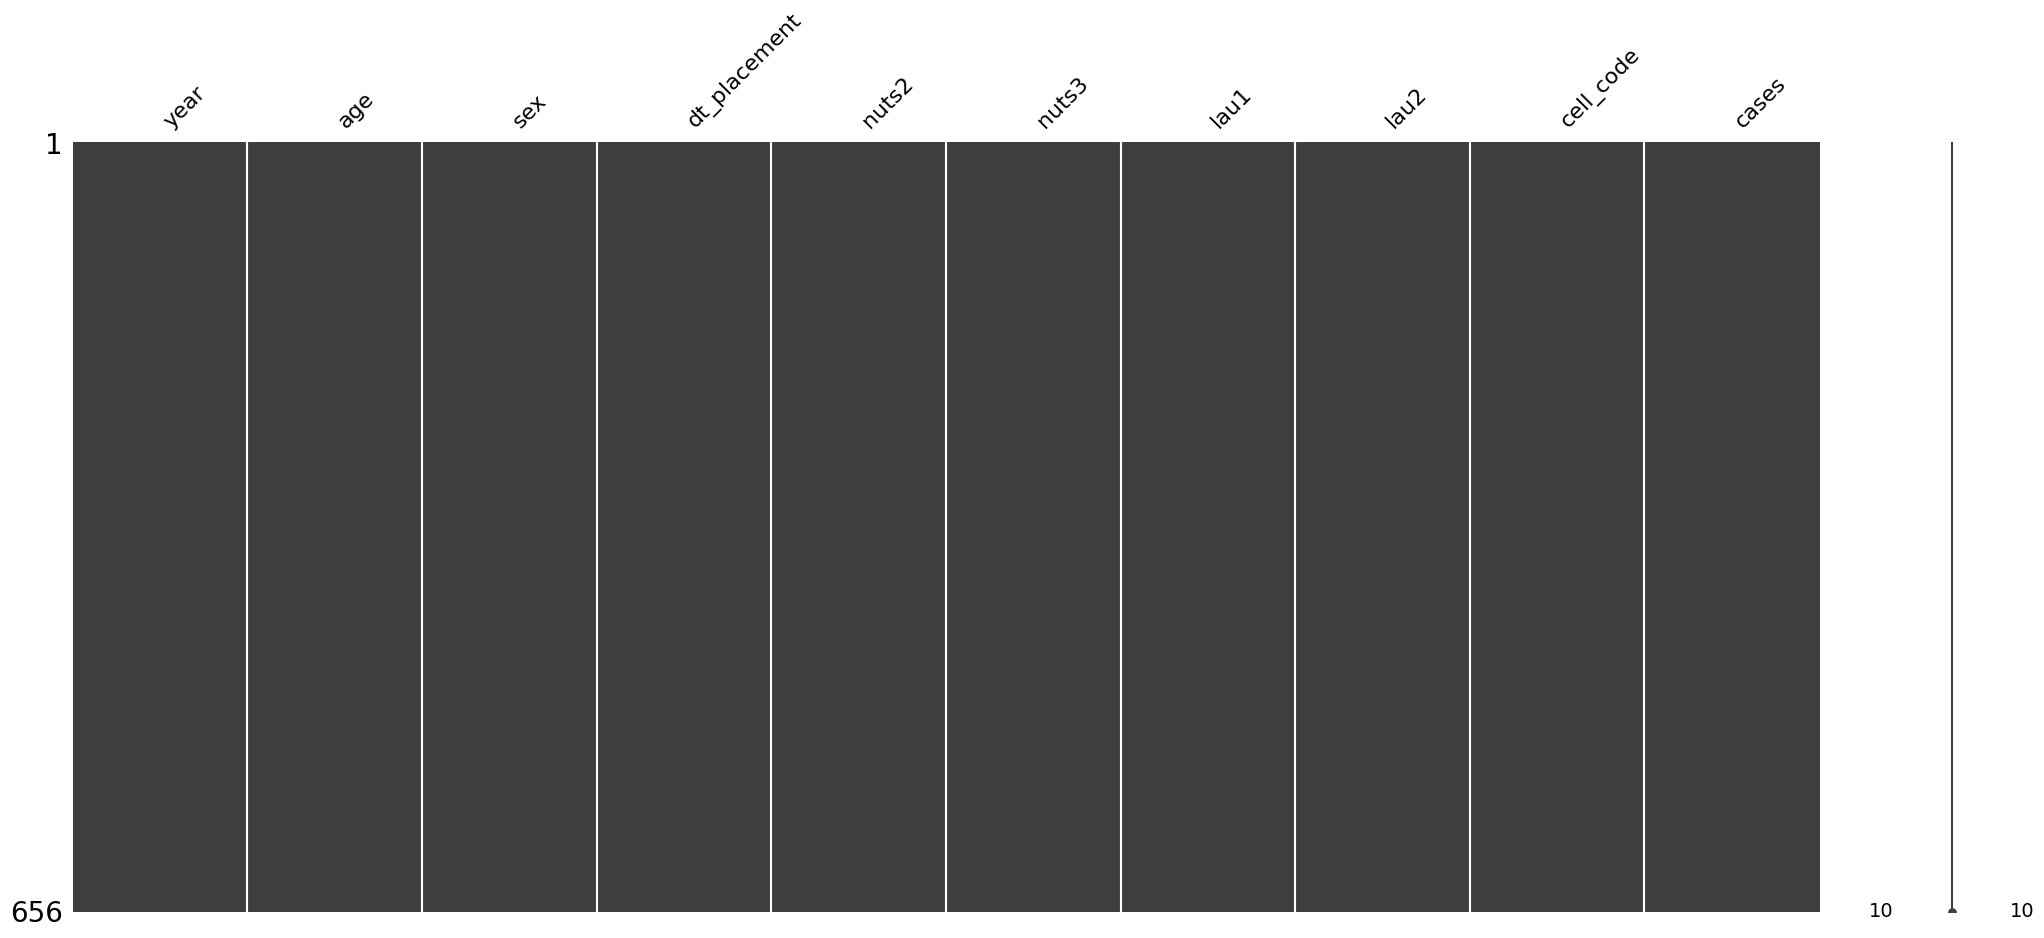

In [40]:
missingno.matrix(dataset)

In [41]:
process_greek(dataset, 'nuts2')
process_greek(dataset, 'nuts3')
process_greek(dataset, 'lau1')
process_greek(dataset, 'lau2')

In [42]:
dataset

,year,age,sex,dt_placement,nuts2,nuts3,lau1,lau2,cell_code,cases
0,2022,65.0,ΑΡΡΕΝ,2022-06-23,κεντρικης μακεδονιας,θεσσαλονικης,αμπελοκηπων μενεμενης,αμπελοκηποι,DU305,1
1,2022,72.0,ΑΡΡΕΝ,2022-07-05,κεντρικης μακεδονιας,θεσσαλονικης,δελτα,ανατολικο,DS287,1
2,2022,78.0,ΑΡΡΕΝ,2022-07-06,κεντρικης μακεδονιας,θεσσαλονικης,χαλκηδονος,βαθυλακκος,DG288,1
3,2022,73.0,ΑΡΡΕΝ,2022-07-04,κεντρικης μακεδονιας,θεσσαλονικης,δελτα,χαλαστρα,DX289,1
4,2022,76.0,ΑΡΡΕΝ,2022-07-05,θεσσαλιας,λαρισας,τεμπων,χειμαδι,HT273,1
...,...,...,...,...,...,...,...,...,...,...
651,2024,54.0,ΑΡΡΕΝ,2024-10-01,αττικης,δυτικης αττικης,μεγαρεων,νεα περαμος,PC346,1
652,2024,59.0,ΑΡΡΕΝ,2024-07-30,κεντρικης μακεδονιας,πελλας,πελλας,παλια πελλα,DH272,1
653,2024,44.0,ΑΡΡΕΝ,2024-10-21,αττικης,κεντρικου τομεα αθηνων,ζωγραφου,ζωγραφου,PF376,1
654,2024,78.0,ΘΗΛΥ,2024-09-15,θεσσαλιας,λαρισας,αγιας,βελικα,HQ299,1


In [43]:
dataset['day'] = dataset['dt_placement'].apply(lambda x : x.day)
dataset['month'] = dataset['dt_placement'].apply(lambda x : x.month)
dataset['year'] = dataset['dt_placement'].apply(lambda x : x.year)

In [44]:
nuts2_processed = dataset['nuts2'].drop_duplicates().sort_values().tolist()
nuts3_processed = dataset['nuts3'].drop_duplicates().sort_values().tolist()
lau1_processed = dataset['lau1'].drop_duplicates().sort_values().tolist()
lau2_processed = dataset['lau2'].drop_duplicates().sort_values().tolist()

In [45]:
dataset

,year,age,sex,dt_placement,nuts2,nuts3,lau1,lau2,cell_code,cases,day,month
0,2022,65.0,ΑΡΡΕΝ,2022-06-23,κεντρικης μακεδονιας,θεσσαλονικης,αμπελοκηπων μενεμενης,αμπελοκηποι,DU305,1,23,6
1,2022,72.0,ΑΡΡΕΝ,2022-07-05,κεντρικης μακεδονιας,θεσσαλονικης,δελτα,ανατολικο,DS287,1,5,7
2,2022,78.0,ΑΡΡΕΝ,2022-07-06,κεντρικης μακεδονιας,θεσσαλονικης,χαλκηδονος,βαθυλακκος,DG288,1,6,7
3,2022,73.0,ΑΡΡΕΝ,2022-07-04,κεντρικης μακεδονιας,θεσσαλονικης,δελτα,χαλαστρα,DX289,1,4,7
4,2022,76.0,ΑΡΡΕΝ,2022-07-05,θεσσαλιας,λαρισας,τεμπων,χειμαδι,HT273,1,5,7
...,...,...,...,...,...,...,...,...,...,...,...,...
651,2024,54.0,ΑΡΡΕΝ,2024-10-01,αττικης,δυτικης αττικης,μεγαρεων,νεα περαμος,PC346,1,1,10
652,2024,59.0,ΑΡΡΕΝ,2024-07-30,κεντρικης μακεδονιας,πελλας,πελλας,παλια πελλα,DH272,1,30,7
653,2024,44.0,ΑΡΡΕΝ,2024-10-21,αττικης,κεντρικου τομεα αθηνων,ζωγραφου,ζωγραφου,PF376,1,21,10
654,2024,78.0,ΘΗΛΥ,2024-09-15,θεσσαλιας,λαρισας,αγιας,βελικα,HQ299,1,15,9


In [46]:
sexes = {'ΘΗΛΥ': 'f', 'ΑΡΡΕΝ': 'm'}
dataset['sex'] = dataset['sex'].map(sexes)  

In [47]:
dataset = dataset.reindex(columns=['age', 'sex', 'dt_placement', 'year', 'month', 'day', 'nuts2', 'nuts3', 'lau1', 'lau2', 'cell_code', 'cases'])

In [48]:
dataset.drop(columns=['age', 'sex'], inplace=True)

In [49]:
dataset

,dt_placement,year,month,day,nuts2,nuts3,lau1,lau2,cell_code,cases
0,2022-06-23,2022,6,23,κεντρικης μακεδονιας,θεσσαλονικης,αμπελοκηπων μενεμενης,αμπελοκηποι,DU305,1
1,2022-07-05,2022,7,5,κεντρικης μακεδονιας,θεσσαλονικης,δελτα,ανατολικο,DS287,1
2,2022-07-06,2022,7,6,κεντρικης μακεδονιας,θεσσαλονικης,χαλκηδονος,βαθυλακκος,DG288,1
3,2022-07-04,2022,7,4,κεντρικης μακεδονιας,θεσσαλονικης,δελτα,χαλαστρα,DX289,1
4,2022-07-05,2022,7,5,θεσσαλιας,λαρισας,τεμπων,χειμαδι,HT273,1
...,...,...,...,...,...,...,...,...,...,...
651,2024-10-01,2024,10,1,αττικης,δυτικης αττικης,μεγαρεων,νεα περαμος,PC346,1
652,2024-07-30,2024,7,30,κεντρικης μακεδονιας,πελλας,πελλας,παλια πελλα,DH272,1
653,2024-10-21,2024,10,21,αττικης,κεντρικου τομεα αθηνων,ζωγραφου,ζωγραφου,PF376,1
654,2024-09-15,2024,9,15,θεσσαλιας,λαρισας,αγιας,βελικα,HQ299,1


In [50]:
dataset.cases.unique()

array([1], dtype=int64)

In [51]:
data_grouped = dataset.groupby(['dt_placement','year','month','day','nuts2','nuts3','lau1','lau2','cell_code'], as_index = False)
dataset = data_grouped.sum()
dataset.reset_index(drop=True, inplace = True)

In [52]:
dataset.cases.unique()

array([1, 2], dtype=int64)

In [53]:
dataset

,dt_placement,year,month,day,nuts2,nuts3,lau1,lau2,cell_code,cases
0,2022-06-23,2022,6,23,κεντρικης μακεδονιας,θεσσαλονικης,αμπελοκηπων μενεμενης,αμπελοκηποι,DU305,1
1,2022-06-23,2022,6,23,κεντρικης μακεδονιας,θεσσαλονικης,κορδελιου ευοσμου,κορδελιο,DS303,1
2,2022-06-29,2022,6,29,κεντρικης μακεδονιας,θεσσαλονικης,θερμης,θερμη,EG313,1
3,2022-07-02,2022,7,2,κεντρικης μακεδονιας,θεσσαλονικης,κορδελιου ευοσμου,ευοσμος,DS305,1
4,2022-07-04,2022,7,4,κεντρικης μακεδονιας,θεσσαλονικης,δελτα,χαλαστρα,DX289,1
...,...,...,...,...,...,...,...,...,...,...
647,2024-10-09,2024,10,9,κεντρικης μακεδονιας,σερρων,ηρακλειας,καρπερη,BT338,1
648,2024-10-10,2024,10,10,θεσσαλιας,λαρισας,λαρισαιων,λαρισα,IC260,1
649,2024-10-13,2024,10,13,ανατολικης μακεδονιας και θρακης,ροδοπης,κομοτηνης,συμβολα,BN515,1
650,2024-10-21,2024,10,21,αττικης,κεντρικου τομεα αθηνων,ζωγραφου,ζωγραφου,PF376,1


In [54]:
dataset.to_csv("../data/GR_WNV_cases_GRID_2022-2024_processed.csv", encoding = enc, index = False)

In [59]:
dataset = convert_multiple_cases(dataset, target_col = 'cases')

In [60]:
dataset

,dt_placement,year,month,day,nuts2,nuts3,lau1,lau2,cell_code,cases
0,2022-06-23,2022,6,23,κεντρικης μακεδονιας,θεσσαλονικης,αμπελοκηπων μενεμενης,αμπελοκηποι,DU305,1
1,2022-06-23,2022,6,23,κεντρικης μακεδονιας,θεσσαλονικης,κορδελιου ευοσμου,κορδελιο,DS303,1
2,2022-06-29,2022,6,29,κεντρικης μακεδονιας,θεσσαλονικης,θερμης,θερμη,EG313,1
3,2022-07-02,2022,7,2,κεντρικης μακεδονιας,θεσσαλονικης,κορδελιου ευοσμου,ευοσμος,DS305,1
4,2022-07-04,2022,7,4,κεντρικης μακεδονιας,θεσσαλονικης,δελτα,χαλαστρα,DX289,1
...,...,...,...,...,...,...,...,...,...,...
651,2024-10-30,2024,10,30,ανατολικης μακεδονιας και θρακης,εβρου,αλεξανδρουπολης,φερες,CR580,1
652,2022-09-02,2022,9,2,θεσσαλιας,λαρισας,λαρισαιων,λαρισα,IB260,1
653,2022-09-17,2022,9,17,κεντρικης μακεδονιας,θεσσαλονικης,καλαμαριας,καλαμαρια,ED307,1
654,2023-09-03,2023,9,3,κεντρικης μακεδονιας,χαλκιδικης,νεας προποντιδας,διονυσιου,FK334,1


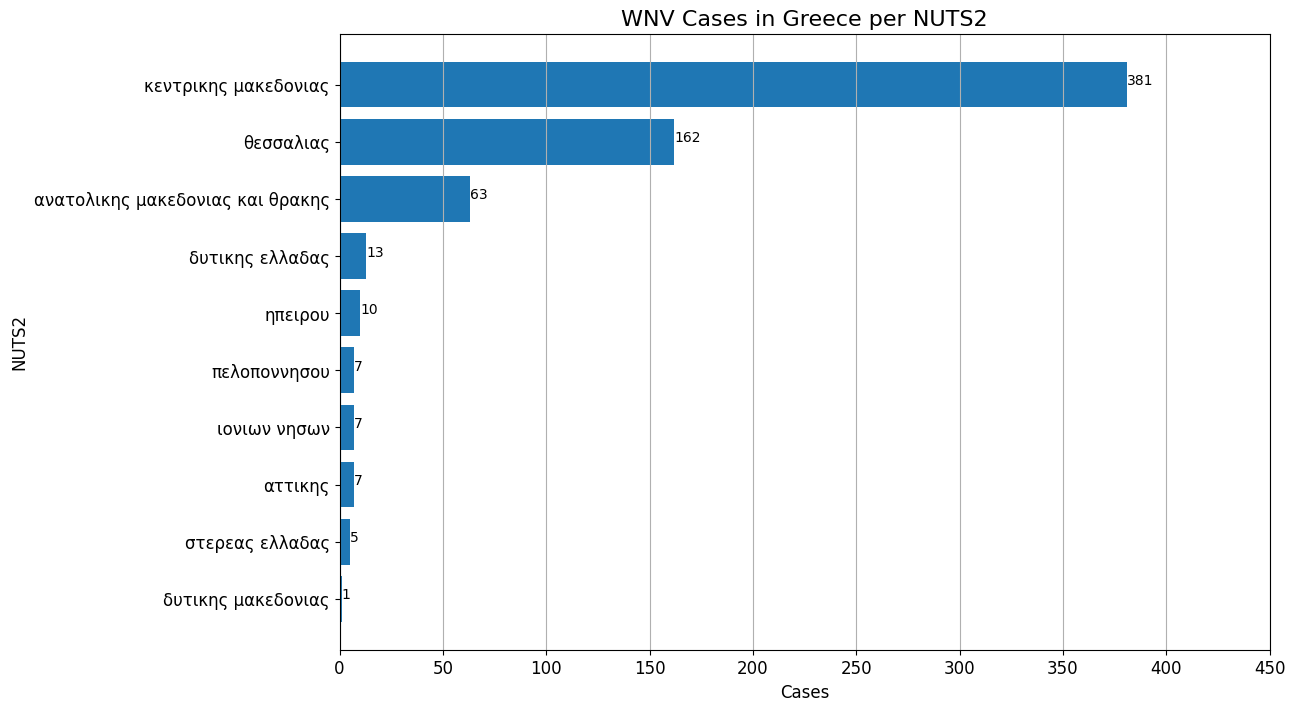

In [82]:
nuts2 = dataset['nuts2'].drop_duplicates().sort_values().tolist()
cases = [len(dataset.query(f"nuts2 == '{nuts2_unit}'")) for nuts2_unit in nuts2]

cases, nuts2 = zip(*sorted(zip(cases, nuts2)))

plt.figure(num = None, figsize = (12,8), facecolor='w', edgecolor='b')
plt.barh(nuts2, cases)

y_t = plt.xticks(np.arange(0, max(cases) + 100, step = 50), size = 12)
x_t = plt.yticks(nuts2, size = 12)
x_l  = plt.ylabel('NUTS2', size = 12)
y_l =  plt.xlabel('Cases', size = 12)
title = plt.title('WNV Cases in Greece per NUTS2', size = 16)
for nuts2, case in zip(nuts2,cases):
    plt.text(case+0.15, nuts2, str(case), size = 10)
ax = plt.gca()
ax.xaxis.grid(True)
plt.show()

In [70]:
nuts_2_IDS = {'αττικης': 'EL30', 
              'βορειου αιγαιου': 'EL41', 
              'νοτιου αιγαιου': 'EL42', 
              'κρητης': 'EL43', 
              'ανατολικης μακεδονιας και θρακης': 'EL51', 
              'κεντρικης μακεδονιας': 'EL52', 
              'δυτικης μακεδονιας': 'EL53', 
              'ηπειρου': 'EL54', 
              'θεσσαλιας': 'EL61', 
              'ιονιων νησων': 'EL62', 
              'δυτικης ελλαδας': 'EL63',
              'στερεας ελλαδας': 'EL64',
              'πελοποννησου': 'EL65'}

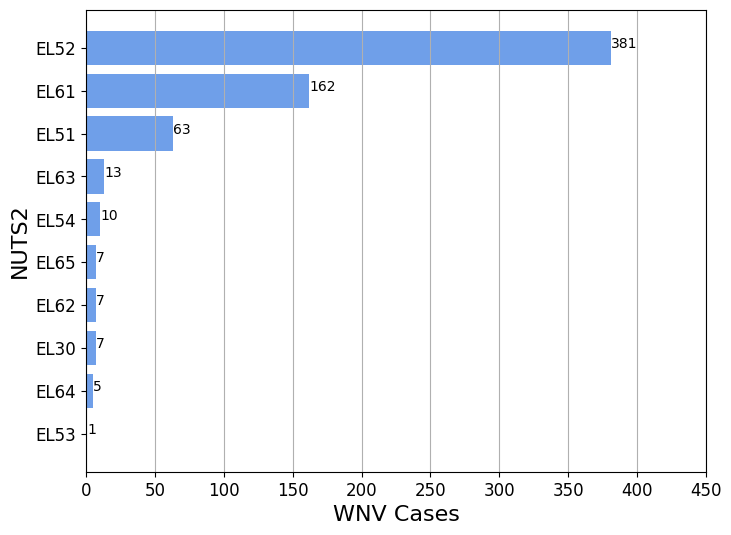

In [81]:
nuts2 = dataset['nuts2'].drop_duplicates().sort_values().tolist()
cases = [len(dataset.query(f"nuts2 == '{nuts2_unit}'")) for nuts2_unit in nuts2]

nuts2_ids = [nuts_2_IDS[key] for key in nuts2 if key in nuts_2_IDS]

cases, nuts2_ids = zip(*sorted(zip(cases, nuts2_ids)))

plt.figure(num = None, figsize = (8,6), facecolor='w', edgecolor='b')
plt.barh(nuts2_ids, cases, color='#6f9fe9')

y_t = plt.xticks(np.arange(0, max(cases) + 100, step = 50), size = 12)
x_t = plt.yticks(nuts2_ids, size = 12)
x_l  = plt.ylabel('NUTS2', size = 16)
y_l =  plt.xlabel('WNV Cases', size = 16)
for nuts2_ids, case in zip(nuts2_ids,cases):
    plt.text(case+0.15, nuts2_ids, str(case), size = 10)
ax = plt.gca()
ax.xaxis.grid(True)
plt.show()

In [65]:
cases

(1, 5, 7, 7, 7, 10, 13, 63, 162, 381)

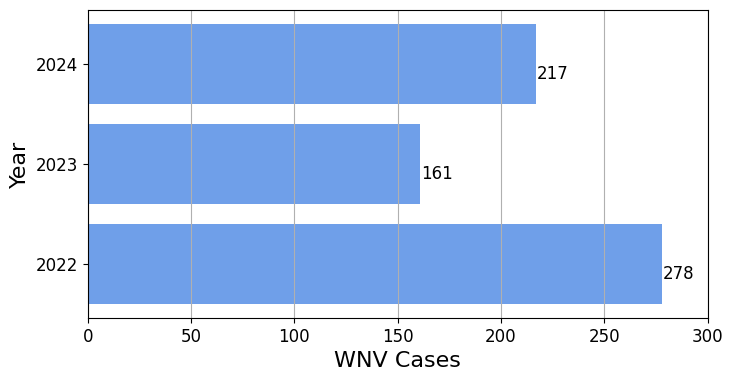

In [78]:
years = [year for year in range(2022, 2025)]
cases = [len(dataset.query(f"year == {year}")) for year in years]

plt.figure(num = None, figsize = (8,4), facecolor='w', edgecolor='b')
plt.barh(years, cases, color='#6f9fe9')

y_t = plt.xticks(np.arange(0, max(cases) + 50, step = 50), size = 12)
x_t = plt.yticks(np.arange(min(years), max(years) + 1, step = 1), size = 12)
x_l  = plt.ylabel('Year', size = 16)
y_l =  plt.xlabel('WNV Cases', size = 16)
for year, case in zip(years,cases):
    plt.text(case+0.15, year-0.15, str(case), size = 12)
ax = plt.gca()
ax.xaxis.grid(True)
plt.show()
###########################################################################################

In [67]:
dataset.month.sort_values().unique()

array([ 6,  7,  8,  9, 10], dtype=int64)

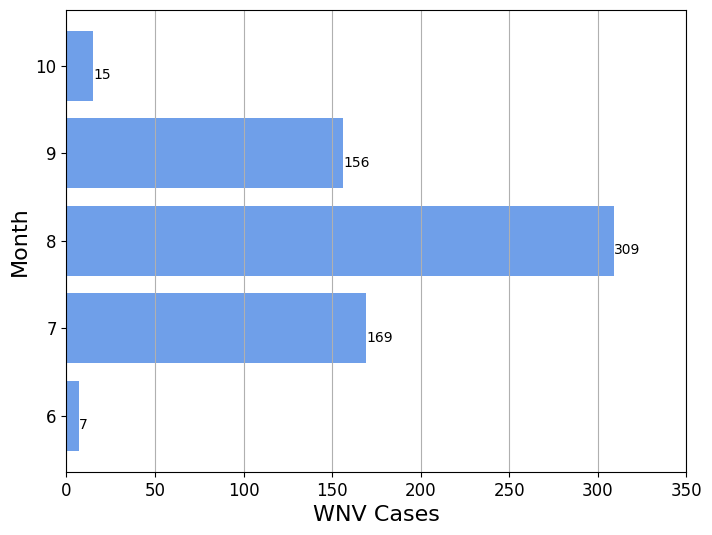

In [83]:
months = [month for month in dataset.month.sort_values().unique()]
cases = [len(dataset.query(f"month == {month}")) for month in months]

plt.figure(num = None, figsize = (8,6), facecolor='w', edgecolor='b')
plt.barh(months, cases, color='#6f9fe9')

y_t = plt.xticks(np.arange(0, max(cases) + 50, step = 50), size = 12)
x_t = plt.yticks(np.arange(min(months), max(months) + 1, step = 1), size = 12)
x_l  = plt.ylabel('Month', size = 16)
y_l =  plt.xlabel('WNV Cases', size = 16)
for year, case in zip(months,cases):
    plt.text(case+0.15, year-0.15, str(case), size = 10)
ax = plt.gca()
ax.xaxis.grid(True)
plt.show()